This work is related to the article:

`Lueders, A., Carpentras, D., & Quayle, M. (2022). A Holistic View on Polarization: Attitudes, Emotions, and Partisanship as Elements of Social Identity Construction.`

Info on hypoteses and preregistration: https://osf.io/bhsza/


In the first part of the notebook we analyze the data that were collected for this experiment. In the second, we repeat the analysis with data from the ANES dataset

# Import the packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import winsound
import scipy.stats as stt
import networkx as nx 

from sklearn.linear_model import LinearRegression

import datetime

# Functions

These are functions that will be used multiple times in the code

As correlation function, we mainly use pearson's correlation. Furthermore, in cases where the variable is binary (as for making the network) pearson's correlation coincides with phi correlation.

In [2]:
# Pearson's correlation
def pears(x,y):
    return stt.pearsonr(x,y)[0]

In [3]:
# Only positive values (and negative ones are set to zero)
def pears_pos(x,y):
    r = stt.pearsonr(x,y)[0]
    if r<0:
        r = 0
    return r

In [4]:
# Correlation which skips the nan (not a number) entries
def corr_nan(x,y):
    x = np.array(x)
    y = np.array(y)
    
    m = np.isnan(x) + np.isnan(y)
    mm = np.logical_not(m)
    
    [r,p] = stt.pearsonr(x[mm],y[mm])
    
    return r

In [5]:
def corr_nan_pos(x,y):
    r = corr_nan(x,y)
    if r<0:
        r = 0
    return r

In [6]:
# Correlation calculated across two (python) dictionaries
def corr_dic(x,y,fun=stt.pearsonr): # x and y are two dictionaries
    xx = []
    yy = []
    
    for key in x:
        if key in y:
            xx.append(x[key])
            yy.append(y[key])
        
    return fun(xx,yy)
    

In [7]:
# Spearman correlation
def spear(x,y):
    return stt.spearmanr(x,y)[0]

def spear_pos(x,y):
    r = spear(x,y)
    if r<0:
        r = 0
    return r

In [8]:
# Support function for making the network of attitudes
# get the required columns

def get_col_values(keys, df):
    
    cols = list()
    
    if type(keys) == type("abc"):
        keys = [keys]
        
    for key in keys:
        col = df[key].values
        cols.append(col)
    
    if len(cols) == 1:
        cols = cols[0]
        
    return cols
        

In [9]:
# Support function for making the network of attitudes
# checks which elements should be removed from the dataframe

def check_element_to_remove(to_remove, string):
    main_var = np.nan
    if type(to_remove) == type('sdf'):
        if to_remove in string:
            main_var = True
        else:
            main_var = False
    elif type(to_remove) == type(["a","b"]):
        main_var = False
        for rem in to_remove:
            if rem in string:
                main_var = True
    return main_var


In [10]:
# Main function from building the network from the dataframe (df)

def make_graph_(df, list_of_nodes, metrics, exclude_same_question=True, print_=False, remove_name=''):
    G = nx.Graph()
    
    if remove_name == '': # should we remove some elements
        remove_el = False
    else:
        remove_el = True
    
    for i, node_i in enumerate(list_of_nodes):
        
        if remove_el and (check_element_to_remove(remove_name, node_i)):# this is one of the elements to remove
            if print_:
                print("Skipping : ", node_i)
        else:
            for j, node_j in enumerate(list_of_nodes):

                if remove_el and (check_element_to_remove(remove_name, node_j)):
                    if print_:
                        print("Skipping : ", node_i)
                    
                else:
                    if print_:
                        n_tot = len(list_of_nodes)**2
                        current = (i*len(list_of_nodes))+(j)
                        print(current,"/",n_tot, " = ", np.round(current/n_tot,decimals=2))

                    if j <= i:
                        continue

                    if exclude_same_question:
                        if node_i.split(sep=':')[0] == node_j.split(sep=':')[0]:
                            # if they belong to the same question
                            continue

                    [c1,c2] = get_col_values([node_i,node_j], df)
                    weight = metrics(c1,c2)
                    G.add_weighted_edges_from([(node_i,node_j,weight)])
    return G

In [11]:
# Function for interpolating colors (only for display purposes in python)

def colorFaderN(C_vec,mix): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    C_vec2 = []
        
    for c in C_vec:
        c = np.array(mpl.colors.to_rgb(c))
        C_vec2.append(c)
    
    mix2 = mix*(len(C_vec)-1)
    i0 = np.floor(mix2)
    i1 = np.ceil(mix2)
    resid = mix2 - i0
    
    i0 = int(i0)
    i1 = int(i1)
    
#     print(i0,i1)

    out = mpl.colors.to_hex((1-resid)*C_vec2[i0] + resid*C_vec2[i1])
    
    return out

In [12]:
# Converts the type of answers (e.g. Strongly disagree) to numbers in a Likert scale

def conv_to_num(col):
    col2 = []
    for el in col:
        if el=='Strongly disagree':
            col2.append(1)
        elif el=='Disagree':
            col2.append(2)
        elif el=='Somewhat disagree':
            col2.append(3)
        elif el=='Neither agree nor disagree':
            col2.append(4)
        elif el== 'Somewhat agree':
            col2.append(5)
        elif el=='Agree':
            col2.append(6)
        elif el=="Strongly agree":
            col2.append(7)
        
        else:
            col2.append(np.nan)
            
    return np.array(col2).astype(float)

# Import and clean the data

Import and clean the experimental dataset.

In [14]:
df0 = pd.read_excel("data_nominal_blind.xlsx")

In [15]:
dictionary = df0.iloc[0,:].copy()
dictionary

dictionary2 = dict()
for c in df0.columns:
    key = c
    ans = df0[c][0]
    dictionary2[key] = ans
# 

In [16]:
# Remove unwanted rows

df1 = df0.iloc[1:,:]
df1

,StartDate,EndDate,Progress,Duration (in seconds),Finished,RecordedDate,Q7,Q9_1,Q9_2,Q9_3,...,Q25,Q23,Abort,Equal,Welfare,Immigrant,Environment,Gay,Gun,AfricanAmerican
1,2021-07-08 12:52:19,2021-07-08 13:00:59,100,519,True,2021-07-08 13:00:59.856000,Yes,Strongly Agree,Somewhat Disagree,Somewhat Agree,...,33,Black or African American,5,5,1,NaN,5,4,1,3
2,2021-07-08 13:04:10,2021-07-08 13:10:09,100,358,True,2021-07-08 13:10:09.529000,Yes,Strongly Disagree,Strongly Agree,Somewhat Disagree,...,25,White,3,2,NaN,1,4,5,4,2
3,2021-07-08 13:14:28,2021-07-08 13:23:13,100,524,True,2021-07-08 13:23:14.264000,Yes,Somewhat Disagree,Somewhat Agree,Neutral,...,40,White,NaN,4,5,4,1,2,5,5
4,2021-07-08 13:22:53,2021-07-08 13:29:48,100,414,True,2021-07-08 13:29:49.006000,Yes,Somewhat Disagree,Neutral,Strongly Disagree,...,30,White,1,NaN,3,5,5,3,1,3
5,2021-07-08 13:24:21,2021-07-08 13:34:51,100,630,True,2021-07-08 13:34:52.209000,Yes,Somewhat Agree,Somewhat Agree,Somewhat Disagree,...,33,White,4,3,NaN,2,1,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,2021-07-08 18:23:39,2021-07-08 18:47:23,100,1424,True,2021-07-08 18:47:23.565000,Yes,Somewhat Agree,Strongly Agree,Somewhat Agree,...,46,White,4,5,1,4,5,5,NaN,2
399,2021-07-08 18:23:29,2021-07-08 18:54:33,100,1864,True,2021-07-08 18:54:34.354000,Yes,Strongly Disagree,Somewhat Agree,Strongly Disagree,...,18,White,3,2,NaN,3,4,4,3,4
400,2021-07-08 19:00:30,2021-07-08 19:13:46,100,796,True,2021-07-08 19:13:47.130000,Yes,Strongly Disagree,Somewhat Disagree,Neutral,...,24,White,5,4,1,1,3,1,5,NaN
401,2021-07-08 19:15:25,2021-07-08 19:21:09,100,344,True,2021-07-08 19:21:10.672000,Yes,Strongly Disagree,Somewhat Agree,Strongly Disagree,...,45,White,3,1,2,2,NaN,4,2,5


# Weights

Re-weight the dataset in order to have more realistic number of democrat and republicans

Info on the weights: https://news.gallup.com/poll/15370/party-affiliation.aspx

In [17]:
df_cpy = df1.copy()
df_cpy = df_cpy[df_cpy["Q13"] == "Republican"]

time_to_copy = 4

df1_t = df1.copy()

for i in range(0,time_to_copy):
    df1_t = df1_t.append(df_cpy, ignore_index=True)
    
df1 = df1_t

<ipython-input-17-488b0499b05c>:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df1_t = df1_t.append(df_cpy, ignore_index=True)


In [18]:
df_cpy = df1.copy()
df_cpy = df_cpy[df_cpy["Q13"] == "Independent"]
# df_cpy
time_to_copy = 3

df1_t = df1.copy()

for i in range(0,time_to_copy):
    df1_t = df1_t.append(df_cpy, ignore_index=True)
    
df1 = df1_t

<ipython-input-18-3b5103d00be2>:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df1_t = df1_t.append(df_cpy, ignore_index=True)


# Make the dataset for the survey

Make a dataset that contains only the items that we want to analyze

In [19]:
columns_for_survey = ["Q9_1",
"Q9_2",
"Q9_3",
"Q9_4",
"Q9_5",
"Q9_6",
"Q9_7",
"Q9_8"]

In [20]:
df_surv0 = df1[columns_for_survey]
df_surv0.head()

,Q9_1,Q9_2,Q9_3,Q9_4,Q9_5,Q9_6,Q9_7,Q9_8
0,Strongly Agree,Somewhat Disagree,Somewhat Agree,Neutral,Strongly Disagree,Neutral,Somewhat Disagree,Somewhat Agree
1,Strongly Disagree,Strongly Agree,Somewhat Disagree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree
2,Somewhat Disagree,Somewhat Agree,Neutral,Somewhat Agree,Neutral,Somewhat Agree,Somewhat Agree,Somewhat Agree
3,Somewhat Disagree,Neutral,Strongly Disagree,Neutral,Somewhat Disagree,Strongly Disagree,Somewhat Disagree,Neutral
4,Somewhat Agree,Somewhat Agree,Somewhat Disagree,Somewhat Agree,Somewhat Disagree,Somewhat Agree,Somewhat Agree,Somewhat Agree


# Calculate Chronbac's alpha

Check the quality of the items by measuring Chronbach's alpha

In [21]:
df_num = df_surv0.copy()
dic_ = {"Strongly Agree":1,"Somewhat Agree":2,"Neutral":3,"Somewhat Disagree":4,"Strongly Disagree":5}
df_num = df_num.replace(dic_)
df_num.head()

,Q9_1,Q9_2,Q9_3,Q9_4,Q9_5,Q9_6,Q9_7,Q9_8
0,1,4,2,3,5,3,4,2
1,5,1,4,1,1,1,1,1
2,4,2,3,2,3,2,2,2
3,4,3,5,3,4,5,4,3
4,2,2,4,2,4,2,2,2


In [22]:
avg_corr = 0
n = 0
for i1, col1 in enumerate(df_num):
    for i2, col2 in enumerate(df_num):
        if i1 > i2:
            c1 = df_num[col1]
            c2 = df_num[col2]

            r = stt.pearsonr(c1,c2)[0]
            r_ = np.abs(r)
            
            n += 1
            avg_corr = ((n-1)*avg_corr + r_)/n

#             print(r_)
print(avg_corr)

0.4389199935389872


In [23]:
l = len(df_num.columns)
alpha = (l*avg_corr) / (1+avg_corr * (l-1))
alpha

0.8622251002612265

# Booleanize/Dummy code the survey

(Resin Method)

This is one of the main steps to produce the network. In order to make it, we need to dummy code it. Meaning that each item-response becomes an indipendent variable. 

For more details about the procedure and its relationship with item-response theory see: https://psyarxiv.com/uzdcg/

In [24]:
df_bool = pd.DataFrame()
df = df_surv0 
list_of_attitudes = []
list_of_questions = columns_for_survey

for quest in list_of_questions:
    values = (df[quest].unique()) # list of unique values of the dataset

    for value in values:
        if type(value) == type('dsf'):
            name = str(quest)+":"+str(value) 
            df_bool[name] = df[quest] == value
            list_of_attitudes.append(name)           
        else:
            if np.isnan(value): # if it's a refused answer
                name = str(quest)+":"+"Ref" 
                try:
                    df_bool[name] = df_bool[name] | df[quest] == value
                except:
                    list_of_attitudes.append(name)
                    df_bool[name] = df[quest] == value
            else:
                name = str(quest)+":"+str(value) 
                df_bool[name] = df[quest] == value
                list_of_attitudes.append(name)


In [25]:
# Show the dummy coded dataframe
df_bool

,Q9_1:Strongly Agree,Q9_1:Strongly Disagree,Q9_1:Somewhat Disagree,Q9_1:Somewhat Agree,Q9_1:Neutral,Q9_2:Somewhat Disagree,Q9_2:Strongly Agree,Q9_2:Somewhat Agree,Q9_2:Neutral,Q9_2:Strongly Disagree,...,Q9_7:Somewhat Disagree,Q9_7:Strongly Agree,Q9_7:Somewhat Agree,Q9_7:Strongly Disagree,Q9_7:Neutral,Q9_8:Somewhat Agree,Q9_8:Strongly Agree,Q9_8:Neutral,Q9_8:Somewhat Disagree,Q9_8:Strongly Disagree
0,True,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,False,True,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,False,False,True,False,False,False,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False
3,False,False,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,False,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,False,False,False,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
958,False,False,False,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
959,False,False,False,False,True,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
960,False,True,False,False,False,False,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False


# Make the network

Use the dummy coded dataframe to build a network of attitudes

In [26]:
remove_name = None

metrics = pears_pos # this is the phi correlation as variables are binary

list_of_nodes = df_bool.columns 
df = df_bool

G = make_graph_(df, list_of_nodes, metrics, exclude_same_question=True, print_=True)

0 / 1600  =  0.0
1 / 1600  =  0.0
2 / 1600  =  0.0
3 / 1600  =  0.0
4 / 1600  =  0.0
5 / 1600  =  0.0
6 / 1600  =  0.0
7 / 1600  =  0.0
8 / 1600  =  0.0
9 / 1600  =  0.01
10 / 1600  =  0.01
11 / 1600  =  0.01
12 / 1600  =  0.01
13 / 1600  =  0.01
14 / 1600  =  0.01
15 / 1600  =  0.01
16 / 1600  =  0.01
17 / 1600  =  0.01
18 / 1600  =  0.01
19 / 1600  =  0.01
20 / 1600  =  0.01
21 / 1600  =  0.01
22 / 1600  =  0.01
23 / 1600  =  0.01
24 / 1600  =  0.02
25 / 1600  =  0.02
26 / 1600  =  0.02
27 / 1600  =  0.02
28 / 1600  =  0.02
29 / 1600  =  0.02
30 / 1600  =  0.02
31 / 1600  =  0.02
32 / 1600  =  0.02
33 / 1600  =  0.02
34 / 1600  =  0.02
35 / 1600  =  0.02
36 / 1600  =  0.02
37 / 1600  =  0.02
38 / 1600  =  0.02
39 / 1600  =  0.02
40 / 1600  =  0.02
41 / 1600  =  0.03
42 / 1600  =  0.03
43 / 1600  =  0.03
44 / 1600  =  0.03
45 / 1600  =  0.03
46 / 1600  =  0.03
47 / 1600  =  0.03
48 / 1600  =  0.03
49 / 1600  =  0.03
50 / 1600  =  0.03
51 / 1600  =  0.03
52 / 1600  =  0.03
53 / 1600  =

580 / 1600  =  0.36
581 / 1600  =  0.36
582 / 1600  =  0.36
583 / 1600  =  0.36
584 / 1600  =  0.36
585 / 1600  =  0.37
586 / 1600  =  0.37
587 / 1600  =  0.37
588 / 1600  =  0.37
589 / 1600  =  0.37
590 / 1600  =  0.37
591 / 1600  =  0.37
592 / 1600  =  0.37
593 / 1600  =  0.37
594 / 1600  =  0.37
595 / 1600  =  0.37
596 / 1600  =  0.37
597 / 1600  =  0.37
598 / 1600  =  0.37
599 / 1600  =  0.37
600 / 1600  =  0.38
601 / 1600  =  0.38
602 / 1600  =  0.38
603 / 1600  =  0.38
604 / 1600  =  0.38
605 / 1600  =  0.38
606 / 1600  =  0.38
607 / 1600  =  0.38
608 / 1600  =  0.38
609 / 1600  =  0.38
610 / 1600  =  0.38
611 / 1600  =  0.38
612 / 1600  =  0.38
613 / 1600  =  0.38
614 / 1600  =  0.38
615 / 1600  =  0.38
616 / 1600  =  0.38
617 / 1600  =  0.39
618 / 1600  =  0.39
619 / 1600  =  0.39
620 / 1600  =  0.39
621 / 1600  =  0.39
622 / 1600  =  0.39
623 / 1600  =  0.39
624 / 1600  =  0.39
625 / 1600  =  0.39
626 / 1600  =  0.39
627 / 1600  =  0.39
628 / 1600  =  0.39
629 / 1600  =  0.39


1171 / 1600  =  0.73
1172 / 1600  =  0.73
1173 / 1600  =  0.73
1174 / 1600  =  0.73
1175 / 1600  =  0.73
1176 / 1600  =  0.74
1177 / 1600  =  0.74
1178 / 1600  =  0.74
1179 / 1600  =  0.74
1180 / 1600  =  0.74
1181 / 1600  =  0.74
1182 / 1600  =  0.74
1183 / 1600  =  0.74
1184 / 1600  =  0.74
1185 / 1600  =  0.74
1186 / 1600  =  0.74
1187 / 1600  =  0.74
1188 / 1600  =  0.74
1189 / 1600  =  0.74
1190 / 1600  =  0.74
1191 / 1600  =  0.74
1192 / 1600  =  0.74
1193 / 1600  =  0.75
1194 / 1600  =  0.75
1195 / 1600  =  0.75
1196 / 1600  =  0.75
1197 / 1600  =  0.75
1198 / 1600  =  0.75
1199 / 1600  =  0.75
1200 / 1600  =  0.75
1201 / 1600  =  0.75
1202 / 1600  =  0.75
1203 / 1600  =  0.75
1204 / 1600  =  0.75
1205 / 1600  =  0.75
1206 / 1600  =  0.75
1207 / 1600  =  0.75
1208 / 1600  =  0.76
1209 / 1600  =  0.76
1210 / 1600  =  0.76
1211 / 1600  =  0.76
1212 / 1600  =  0.76
1213 / 1600  =  0.76
1214 / 1600  =  0.76
1215 / 1600  =  0.76
1216 / 1600  =  0.76
1217 / 1600  =  0.76
1218 / 1600  

# Heatmaps

We can add some variables for each node so we can color code them (i.e. make a heatmap of the nodes)

Colors depending on the level of the attitude

In [27]:
dic_ = dict()

for node in G.nodes:
    name = node.split(':')
    
    if name[0] == "Q9_3" or name[0] == "Q9_1":
        if name[1] == "Strongly Agree":
            dic_[node] = 5
        if name[1] == "Somewhat Agree":
            dic_[node] = 4
        if name[1] == "Neutral":
            dic_[node] = 3
        if name[1] == "Somewhat Disagree":
            dic_[node] = 2
        if name[1] == "Strongly Disagree":
            dic_[node] = 1
    else:
        if name[1] == "Strongly Agree":
            dic_[node] = 1
        if name[1] == "Somewhat Agree":
            dic_[node] = 2
        if name[1] == "Neutral":
            dic_[node] = 3
        if name[1] == "Somewhat Disagree":
            dic_[node] = 4
        if name[1] == "Strongly Disagree":
            dic_[node] = 5

nx.set_node_attributes(G, dic_, "level")


Heatmap of political self identity

In [28]:
dic_ = dict()

for type_ in ["continuous","discrete"]:
    for id_ in ['Republican', 'Independent', 'Democrat']:
        col_id = df1["Q13"]==id_
        for node in G.nodes:
            col_node = df_bool[node]

            r = stt.pearsonr(col_node,col_id)[0]
            
            if type_=="discrete":
                dic_[node] = np.sign(r)
            else:
                dic_[node] = r

        nx.set_node_attributes(G, dic_, id_+"_"+type_)

Heatmap of evaluation of rep and dem

In [29]:
dic_ = dict()

col_evaluation = df1["Q15_1"]-df1["Q15_2"]

for node in G.nodes:
    col_node = df_bool[node]

    r = stt.pearsonr(col_node,col_evaluation)[0]
    
    dic_[node] = r


nx.set_node_attributes(G, dic_, "evaluation")

In [30]:
dic_ = dict()

col_evaluation = df1["Q15_1"]-df1["Q15_2"]

for node in G.nodes:
    col_node = df_bool[node]

    r = stt.pearsonr(col_node,col_evaluation)[0]
    
    dic_[node] = np.sign(r)

nx.set_node_attributes(G, dic_, "evaluation_discr")

Heatmap of differential identification

In [31]:
dic_ans_10 = {"Strongly agree":1,"Agree":2,"Somewhat agree":3,"Neither agree nor disagree":4,
             "Somewhat disagree":5,"Disagree":6,"Strongly disagree":7}


id_dem = df1["Q17_1"].replace(dic_ans_10) # dem
id_rep = df1["Q17_2"].replace(dic_ans_10) # dem
id_diff = id_dem - id_rep


dic_ = dict()

col_evaluation = id_diff

for node in G.nodes:
    col_node = df_bool[node]

    r = stt.pearsonr(col_node,col_evaluation)[0]
    
    dic_[node] = r

nx.set_node_attributes(G, dic_, "diff_identity")

Heatmap of the vignette position

In [32]:
dictionary_attitudes = {"Abort":"Q9_1",
                       "Equal":"Q9_2",
                       "immigrant":"Q9_3",
                       "welfare":"Q9_4",
                       "gay":"Q9_5",
                       "env":"Q9_6",
                       "gun":"Q9_7",
                       "african":"Q9_8",}

dic_att_inv = {dictionary_attitudes[key]:key for key in dictionary_attitudes}

In [33]:
dic_evaluation={"Strongly Agree":5,"Somewhat Agree":4,"Neutral":3,"Somewhat Disagree":2,"Strongly Disagree":1}

In [34]:
col_rename = {"Equal4_dem_1.1":"Equal5_dem_1",
             "immigrant4_dem_1.1":"immigrant5_dem_1",
             "immigrant4_rep_1.1":"immigrant5_rep_1",
             "Immigrant5_rep_1":"immigrant5_rep_1"}
df1.rename(columns = col_rename, inplace = True)

In [35]:
dic_ = dict()


for node in G.nodes:
    col_node = df_bool[node]
    
    # find the equivalent vignette
    parts = node.split(":")
    name_1 = dic_att_inv[parts[0]]
    name_2 = str(dic_evaluation[parts[1]])
    
    name_full = name_1+name_2

    col_x1 = df1[name_full+"_dem_1"]
    col_x2 = df1[name_full+"_rep_1"]
    
    col_diff_ = col_x1-col_x2
    
    mean_ = np.mean(col_diff_)
    
    dic_[node] = mean_
    
    
nx.set_node_attributes(G, dic_, "vignette_posit")

Heatmap of vignette position (as correlation)

In [36]:
dic_ = dict()

for node in G.nodes:
    col_node = df_bool[node]
    
    # find the equivalent vignette
    parts = node.split(":")
    name_1 = dic_att_inv[parts[0]]
    name_2 = str(dic_evaluation[parts[1]])
    
    name_full = name_1+name_2
    
    col_x1 = df1[name_full+"_dem_1"]
    col_x2 = df1[name_full+"_rep_1"]
    
    col_diff_ = col_x1-col_x2
    col_diff_ = np.array(col_diff_).astype(float)

    r = corr_nan(col_node,col_diff_)
    
    dic_[node] = r

nx.set_node_attributes(G, dic_, "position_corr")

Heatmap (or node size) of how often each node is selected

In [37]:
dic_ = dict()
for node in G.nodes:
    col_node = df_bool[node]
    
    sum_ = np.sum(col_node)
    
    dic_[node] = sum_
    
    
nx.set_node_attributes(G, dic_, "node_selection")


# Save the network

In [38]:
filename = 'NAME_OF_THE_FILE'
path = "DIRECTORY_WHERE_TO_SAVE"
nx.write_gexf(G,path+filename+'.gexf')

# Calculate the x-coordinate

To calculate the different hypotheses, we need to get the position of each node (in the x-y space) and then use it to calculate the position of each person.

In [39]:
# Use spring layout to calculate the position of each node

pos = nx.spring_layout(G,iterations=50000*10)

pos2 = [[],[]]
key_list = []
for key in pos:
    pos2[0].append(pos[key][0])
    pos2[1].append(pos[key][1])
    key_list.append(key)
    
pos3 = []
keys_vec = []
for key in pos:
    pos3.append([pos[key][0],pos[key][1]])
    keys_vec.append(key)

Rotate the network in such a way that the main axis coincide with the x axis (using principal component analysis)

In [40]:
from sklearn.decomposition import PCA

In [41]:
pca = PCA(n_components=2)
pca.fit(pos3)
x_pca = pca.transform(pos3)

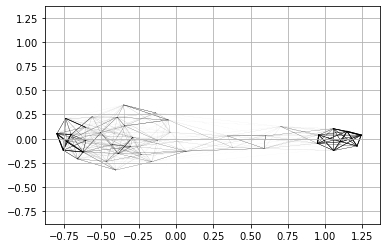

In [42]:
# Show the result

plt.figure()
xx = x_pca[:,0]
yy = x_pca[:,1]

mm = min(xx)*1.1
MM = max(xx)*1.1

koef = 3
for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1,key2)['weight']

            if w > 0.:
                plt.plot([xx[i1],xx[i2]],[yy[i1],yy[i2]],'k',linewidth=koef*w**2,zorder=1)

index = np.array(range(0,len(xx)))+1

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.grid()

Calculate the x-cord of each attitutde

In [43]:
xcor_att = dict()
ycor_att = dict()

min_ = 1000
max_ = -min_

for i,key in enumerate(keys_vec):
    xcor_att[key] = xx[i]
    ycor_att[key] = yy[i]
    
    if xx[i]<min_:
        min_ = xx[i]
        
    if xx[i]>max_:
        max_= xx[i]


In [44]:
# renormalize x between -1 and 1
for key in xcor_att:
    val = xcor_att[key]
    
    val1 = (val-min_)/(max_-min_)
    val2 = (val1*2) - 1
    
    xcor_att[key] = val2

Calculate the x-coordinale for each person

In [45]:
quests = ["Q9_1","Q9_2","Q9_3","Q9_4","Q9_5","Q9_6","Q9_7","Q9_8"]

mean_x_cor_pep = []
std_x_cor_pep = []
mean_y_cor_pep = []

n_norm= 1

x_transform = lambda vec: vec

for i,_ in enumerate(df1.iloc[:,0]): # for each person
    line = df1.iloc[i,:]
    
    ans = line[quests]
    
    x_cor_p = []
    y_cor_p = []
    
    for j,el in enumerate(ans):
        
        x_cor_p.append(xcor_att[quests[j]+":"+el])
        y_cor_p.append(ycor_att[quests[j]+":"+el])

    x_cor_p = np.array(x_cor_p)
    
    x_cor_p = x_transform(x_cor_p)
    
    mean_ = np.mean(x_cor_p)
    mean_x_cor_pep.append(mean_) 
    
    
    mean_y_cor_pep.append(np.mean(y_cor_p))
    
    std_x_cor_pep.append(np.std(x_cor_p))
    
df1["x_cor"] = mean_x_cor_pep
df1["y_cor"] = mean_y_cor_pep

df1["x_std"] = std_x_cor_pep
    


# Test the main hypoteses

See the article for a full explanation of the main hypotheses

### H1

In [46]:
dic_ans_10 = {"Strongly agree":1,"Agree":2,"Somewhat agree":3,"Neither agree nor disagree":4,
             "Somewhat disagree":5,"Disagree":6,"Strongly disagree":7}


id_dem = df1["Q17_1"].replace(dic_ans_10) # dem
id_rep = df1["Q17_2"].replace(dic_ans_10) # dem
# id_rep
id_diff = id_dem - id_rep

stt.pearsonr(-id_diff,df1["x_cor"])

(0.7236038647613638, 9.46465647895022e-157)

### H2

In [47]:
col_evaluation = df1["Q15_1"]-df1["Q15_2"]
stt.pearsonr(col_evaluation,df1["x_cor"])

(0.7214362818446914, 2.2055643270655064e-155)

### H3

In [48]:
att_names = []
x_cor_atts = []
score_atts = []
estimation = []

score_atts_dic = dict()

for node in G.nodes:
    att_names.append(node)
    
    col_node = df_bool[node]
    
    # find the equivalent vignette
    parts = node.split(":")
    name_1 = dic_att_inv[parts[0]]
    name_2 = str(dic_evaluation[parts[1]])
    
    name_full = name_1+name_2
    
    col_x1 = df1[name_full+"_dem_1"]
    col_x2 = df1[name_full+"_rep_1"]
    
    col_diff_ = col_x1-col_x2
    
    mean_ = np.mean(col_diff_)
    
    estimation.append(mean_)
    
    # Find the cordinates
    
    x_cor_atts.append(xcor_att[node])
    
    if "Q9_1" in node or "Q9_3" in node:
        score_atts.append(6-int(name_full[-1]))
        score_atts_dic[node] = 6-int(name_full[-1])
    else:
        score_atts.append(int(name_full[-1]))
        score_atts_dic[node] = int(name_full[-1])
    
stt.pearsonr(x_cor_atts,estimation)

(0.9045606536644841, 1.2058563500696729e-15)

### H4

In [49]:
distance_cor = []

evaluation = []

codice = []

for i,_ in enumerate(df1.iloc[:,0]): # for each person in the dataset
    line = df1.iloc[i,:]
    
    for node in G.nodes:
        att_names.append(node)

        col_node = df_bool[node]

        # find the equivalent vignette
        parts = node.split(":")
        name_1 = dic_att_inv[parts[0]]
        name_2 = str(dic_evaluation[parts[1]])


        name_full = name_1+name_2
        if name_full == "immigrant2":
            name_full = "Immigrant2"
        elif name_full == "welfare3":
            name_full = "weöfare3"
        
        evaluation_value = line[name_full+"_feel_1"]
        
        
        if not np.isnan(evaluation_value):
            

            evaluation.append(evaluation_value)

            codice.append(str(i)+"_"+name_full)
            
            x_pers = line["x_cor"]
            x_att = xcor_att[node]
            
            dist_corr = np.abs(x_pers-x_att)
            
            distance_cor.append(dist_corr)
                

In [50]:
evaluation = np.array(evaluation)
distance_cor = np.array(distance_cor)

stt.pearsonr(-distance_cor,evaluation)

(0.497199389055479, 0.0)

# Heatmap in order

Heatmap of the nodes, but this time they are not displayed in the network, but in the position determined by item and level

In [51]:
evaluations = []
positions = []

max_eva = 0
max_posit = 0

for q in range(1,9):
#     evaluations.append([])
#     positions.append([])
    
    eva_ = []
    posit_ = []
    
    for lev in ["Strongly Agree", "Somewhat Agree", "Neutral", "Somewhat Disagree", "Strongly Disagree"]:
        nod = "Q9_"+str(q)+":"+lev
        eva = nx.get_node_attributes(G,"evaluation")[nod]
        posit = nx.get_node_attributes(G,"position_corr")[nod]
        
#         print(eva, np.abs(eva), max_eva)
        
        if np.abs(eva)> max_eva:
            max_eva = np.abs(eva)
            
        if np.abs(posit)> max_posit:
            max_posit = np.abs(posit)
        
        eva_.append(eva)
        posit_.append(posit)
    
    evaluations.append(eva_)
    positions.append(posit_)

### Evaluation plot

Heatmap of the evaluation (blue = more dem; red = more rep)

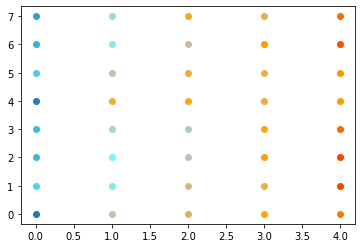

In [52]:
import matplotlib as mpl

c1='#1f77b4' #blue
c2 = "#66ffff" # cyan
c3='#c0c0c0' # grey
c_grey = "#737373" # darker grey
c4 = "orange" 
c5='red' 

norm_val = max_eva
vec = evaluations

Cvec = [c5,c4,c3,c2,c1]
# Cvec = [c5,c4,c3,c_grey,c3,c2,c1]



plt.figure()
for i0, ev_line in enumerate(vec):
#     print(i0)
    if (i0 == 0) or (i0 == 2):
        invert = True
    else:
        invert = False
        
    for i1, val in enumerate(ev_line):
        val2 = 0.5+(val/norm_val)/2
#         print(val, val2)
        col = colorFaderN(Cvec,val2)
        if invert:
            plt.plot([4-i1],[i0],'o', color=col)
            
        else:
            plt.plot([i1],[i0],'o', color=col)

### Levels plot

Heatmap of the levels of each item (blue = more dem; red = more rep)

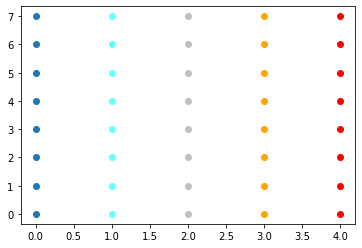

In [53]:
c1='#1f77b4' #blue
c2 = "#66ffff" # cyan
c3='#c0c0c0' # grey
c_grey = "#737373" # darker grey
c4 = "orange" 
c5='red' 

norm_val = max_eva
vec = evaluations

Cvec = [c5,c4,c3,c2,c1]
# Cvec = [c5,c4,c3,c_grey,c3,c2,c1]



plt.figure()
for i0, ev_line in enumerate(vec):
    for i1, val in enumerate(ev_line):
        val2 = i1/4
        col = colorFaderN(Cvec,val2)
        plt.plot([4-i1],[i0],'o', color=col)
        

# Repeat with ANES

Repeat the previous analysis with the ANES data

In [55]:
anes_data_filename = "anes_timeseries_2020_csv_20210719.csv" # insert here the name of the file
anes20 = pd.read_csv(anes_data_filename)

<ipython-input-55-6f4fc92127a2>:2: DtypeWarning: Columns (15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  anes20 = pd.read_csv(anes_data_filename)


### Clean the df

In [56]:
# Change the name of the variables to make them understandable
dic2020 = {"V201336":"abortion",  "V202257":"income", "V201417":"immigrants",
             "V201312":"welfare","V201416":"gay","V201262":"environment",
             "V202337":"gun", "V201258":"black"}

dic2_2020 = {dic2020[key]:key for key in dic2020}

In [57]:
anes20_3 = pd.DataFrame()

for col in dic2020.values(): 
    if col == "year":
        continue
    anes20_3[col] = anes20[dic2_2020[col]].astype(float)
    
anes20_3["year"] = ((anes20[dic2_2020[col]].astype(float)*0)+2020).astype(int)

In [58]:
# Add the feeling thermometer and the party
anes20_3["Thermo"] = anes20["V201156"] - anes20["V201157"] 
anes20_3["PartyRegistr"] = anes20["V201018"]

In [59]:
# Clean the party variable
for col in anes20_3.columns:
    if col == "PartyRegistr":
        c_ = anes20_3[col]
        c_[(c_ < 1) + (c_ > 10)] = np.nan    
        c_[c_>2] = np.nan

<ipython-input-59-aaac645d7296>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_[(c_ < 1) + (c_ > 10)] = np.nan


In [60]:
anes20_3

,abortion,income,immigrants,welfare,gay,environment,gun,black,year,Thermo,PartyRegistr
0,2.0,1.0,1.0,2.0,3.0,7.0,3.0,7.0,2020,-85,2.0
1,4.0,3.0,3.0,2.0,1.0,99.0,3.0,4.0,2020,-50,NaN
2,4.0,1.0,4.0,1.0,1.0,1.0,1.0,3.0,2020,60,NaN
3,1.0,1.0,1.0,3.0,1.0,1.0,3.0,99.0,2020,-20,2.0
4,3.0,3.0,2.0,3.0,2.0,4.0,3.0,6.0,2020,-50,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8275,3.0,2.0,2.0,1.0,2.0,4.0,3.0,5.0,2020,-100,2.0
8276,4.0,3.0,1.0,1.0,3.0,4.0,3.0,5.0,2020,-30,2.0
8277,2.0,3.0,3.0,3.0,1.0,5.0,1.0,4.0,2020,35,1.0
8278,3.0,2.0,3.0,2.0,2.0,5.0,3.0,7.0,2020,-70,NaN


Make the dataframe that will be dummy coded

In [61]:
df20_4 = anes20_3.copy()
df20_4 = df20_4.drop(columns=['year', "Thermo", "PartyRegistr"])
for col in df20_4.columns:
    if col=="immigrants":
        df20_4[col].replace({1:"Incr.lot",2:"Incr.litt",3:"Dec.litt",4:"Dec.lot"}, inplace=True)
    elif col=="welfare":
        df20_4[col].replace({1:"Incr",3:"Same",2:"Dec"}, inplace=True)
    elif col=="gay":
        df20_4[col].replace({1:"Yes",2:"No", 3:"DK"}, inplace=True)
    elif col=="gun":
        df20_4[col].replace({1:"Difficult",3:"Same", 2:"Easier"}, inplace=True)
    elif col=="abortion":
        df20_4[col].replace({1:"Never",2:"Rarely", 3:"Often", 4:"Always"}, inplace=True)
    elif col=="income":
        df20_4[col].replace({1:"Favor",2:"Oppose", 3:"Neutral"}, inplace=True)
    elif col=="environment":
        df20_4[col].replace({1:"Tough++",2:"Tough+", 3:"Tough",4:"Neutral", 5:"Weaker",
                         6:"Weaker+", 7:"Weaker++"}, inplace=True)
    elif col=="black":
        df20_4[col].replace({1:"Help++",2:"Help+", 3:"Help",4:"Neutral", 5:"NoHelp",
                         6:"NoHelp+", 7:"NoHelp++"}, inplace=True)

# Replace with nan
for col in df20_4.columns:
    if col=="year":
        continue
    line = df20_4[col]
    line[line.apply(type)!=type('sdf')] = np.nan # replace the non-string with nan
    
df20_4 = df20_4.dropna(axis=0)


In [62]:
df20_4

,abortion,income,immigrants,welfare,gay,environment,gun,black
0,Rarely,Favor,Incr.lot,Dec,DK,Weaker++,Same,NoHelp++
2,Always,Favor,Dec.lot,Incr,Yes,Tough++,Difficult,Help
4,Often,Neutral,Incr.litt,Same,No,Neutral,Same,NoHelp+
6,Often,Neutral,Incr.litt,Incr,Yes,Weaker,Difficult,NoHelp++
10,Never,Neutral,Dec.litt,Incr,DK,Tough++,Difficult,Help++
...,...,...,...,...,...,...,...,...
8275,Often,Oppose,Incr.litt,Incr,No,Neutral,Same,NoHelp
8276,Always,Neutral,Incr.lot,Incr,DK,Neutral,Same,NoHelp
8277,Rarely,Neutral,Dec.litt,Same,Yes,Weaker,Difficult,Neutral
8278,Often,Oppose,Dec.litt,Dec,No,Weaker,Same,NoHelp++


### Booleanize/dummy-code the dataframe

In [63]:
# Booleanize the df
df_bool = pd.DataFrame()
dft = df20_4
df = dft.copy()
# df = df_full
list_of_attitudes = []
list_of_questions = dft.columns

for quest in list_of_questions:
    values = (df[quest].unique()) # list of unique values of the dataset
    
    for value in values:
        if type(value) == type('dsf'):
            name = str(quest)+":"+str(value) 
            df_bool[name] = df[quest] == value
            list_of_attitudes.append(name)           
        else:
            if np.isnan(value): # if it's a refused answer
                name = str(quest)+":"+"Ref" 
                try:
                    df_bool[name] = df_bool[name] | df[quest] == value
                except:
                    list_of_attitudes.append(name)
                    df_bool[name] = df[quest] == value
            else:
                name = str(quest)+":"+str(value) 
                df_bool[name] = df[quest] == value
                list_of_attitudes.append(name)


In [64]:
df_bool

,abortion:Rarely,abortion:Always,abortion:Often,abortion:Never,income:Favor,income:Neutral,income:Oppose,immigrants:Incr.lot,immigrants:Dec.lot,immigrants:Incr.litt,...,gun:Same,gun:Difficult,gun:Easier,black:NoHelp++,black:Help,black:NoHelp+,black:Help++,black:Neutral,black:Help+,black:NoHelp
0,True,False,False,False,True,False,False,True,False,False,...,True,False,False,True,False,False,False,False,False,False
2,False,True,False,False,True,False,False,False,True,False,...,False,True,False,False,True,False,False,False,False,False
4,False,False,True,False,False,True,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False
6,False,False,True,False,False,True,False,False,False,True,...,False,True,False,True,False,False,False,False,False,False
10,False,False,False,True,False,True,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8275,False,False,True,False,False,False,True,False,False,True,...,True,False,False,False,False,False,False,False,False,True
8276,False,True,False,False,False,True,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
8277,True,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
8278,False,False,True,False,False,False,True,False,False,False,...,True,False,False,True,False,False,False,False,False,False


Make the network

In [65]:
remove_name = None# ["essround","cntry","Ref"]

# metrics = phi_pos
metrics = corr_nan_pos

list_of_nodes = df_bool.columns # columns_for_survey # 

df = df_bool

G = make_graph_(df, list_of_nodes, metrics, exclude_same_question=True, print_=True)

0 / 1156  =  0.0
1 / 1156  =  0.0
2 / 1156  =  0.0
3 / 1156  =  0.0
4 / 1156  =  0.0
5 / 1156  =  0.0
6 / 1156  =  0.01
7 / 1156  =  0.01
8 / 1156  =  0.01
9 / 1156  =  0.01
10 / 1156  =  0.01
11 / 1156  =  0.01
12 / 1156  =  0.01
13 / 1156  =  0.01
14 / 1156  =  0.01
15 / 1156  =  0.01
16 / 1156  =  0.01
17 / 1156  =  0.01
18 / 1156  =  0.02
19 / 1156  =  0.02
20 / 1156  =  0.02
21 / 1156  =  0.02
22 / 1156  =  0.02
23 / 1156  =  0.02
24 / 1156  =  0.02
25 / 1156  =  0.02
26 / 1156  =  0.02
27 / 1156  =  0.02
28 / 1156  =  0.02
29 / 1156  =  0.03
30 / 1156  =  0.03
31 / 1156  =  0.03
32 / 1156  =  0.03
33 / 1156  =  0.03
34 / 1156  =  0.03
35 / 1156  =  0.03
36 / 1156  =  0.03
37 / 1156  =  0.03
38 / 1156  =  0.03
39 / 1156  =  0.03
40 / 1156  =  0.03
41 / 1156  =  0.04
42 / 1156  =  0.04
43 / 1156  =  0.04
44 / 1156  =  0.04
45 / 1156  =  0.04
46 / 1156  =  0.04
47 / 1156  =  0.04
48 / 1156  =  0.04
49 / 1156  =  0.04
50 / 1156  =  0.04
51 / 1156  =  0.04
52 / 1156  =  0.04
53 / 1156

543 / 1156  =  0.47
544 / 1156  =  0.47
545 / 1156  =  0.47
546 / 1156  =  0.47
547 / 1156  =  0.47
548 / 1156  =  0.47
549 / 1156  =  0.47
550 / 1156  =  0.48
551 / 1156  =  0.48
552 / 1156  =  0.48
553 / 1156  =  0.48
554 / 1156  =  0.48
555 / 1156  =  0.48
556 / 1156  =  0.48
557 / 1156  =  0.48
558 / 1156  =  0.48
559 / 1156  =  0.48
560 / 1156  =  0.48
561 / 1156  =  0.49
562 / 1156  =  0.49
563 / 1156  =  0.49
564 / 1156  =  0.49
565 / 1156  =  0.49
566 / 1156  =  0.49
567 / 1156  =  0.49
568 / 1156  =  0.49
569 / 1156  =  0.49
570 / 1156  =  0.49
571 / 1156  =  0.49
572 / 1156  =  0.49
573 / 1156  =  0.5
574 / 1156  =  0.5
575 / 1156  =  0.5
576 / 1156  =  0.5
577 / 1156  =  0.5
578 / 1156  =  0.5
579 / 1156  =  0.5
580 / 1156  =  0.5
581 / 1156  =  0.5
582 / 1156  =  0.5
583 / 1156  =  0.5
584 / 1156  =  0.51
585 / 1156  =  0.51
586 / 1156  =  0.51
587 / 1156  =  0.51
588 / 1156  =  0.51
589 / 1156  =  0.51
590 / 1156  =  0.51
591 / 1156  =  0.51
592 / 1156  =  0.51
593 / 1156 

1015 / 1156  =  0.88
1016 / 1156  =  0.88
1017 / 1156  =  0.88
1018 / 1156  =  0.88
1019 / 1156  =  0.88
1020 / 1156  =  0.88
1021 / 1156  =  0.88
1022 / 1156  =  0.88
1023 / 1156  =  0.88
1024 / 1156  =  0.89
1025 / 1156  =  0.89
1026 / 1156  =  0.89
1027 / 1156  =  0.89
1028 / 1156  =  0.89
1029 / 1156  =  0.89
1030 / 1156  =  0.89
1031 / 1156  =  0.89
1032 / 1156  =  0.89
1033 / 1156  =  0.89
1034 / 1156  =  0.89
1035 / 1156  =  0.9
1036 / 1156  =  0.9
1037 / 1156  =  0.9
1038 / 1156  =  0.9
1039 / 1156  =  0.9
1040 / 1156  =  0.9
1041 / 1156  =  0.9
1042 / 1156  =  0.9
1043 / 1156  =  0.9
1044 / 1156  =  0.9
1045 / 1156  =  0.9
1046 / 1156  =  0.9
1047 / 1156  =  0.91
1048 / 1156  =  0.91
1049 / 1156  =  0.91
1050 / 1156  =  0.91
1051 / 1156  =  0.91
1052 / 1156  =  0.91
1053 / 1156  =  0.91
1054 / 1156  =  0.91
1055 / 1156  =  0.91
1056 / 1156  =  0.91
1057 / 1156  =  0.91
1058 / 1156  =  0.92
1059 / 1156  =  0.92
1060 / 1156  =  0.92
1061 / 1156  =  0.92
1062 / 1156  =  0.92
1063

### Heatmap

Get the values for color-coding the nodes (here just based on the level)

In [66]:
dic_ = dict()

for node in G.nodes:
    [quest_,ans] = node.split(":")

    if quest_=="immigrants":
        lev = {"Incr.lot":3,"Incr.litt":3,"Dec.litt":1,"Dec.lot":1}[ans]
        dic_[node] = lev
    elif quest_=="welfare":
        lev = {"Incr":1,"Same":2,"Dec":3}[ans]
        dic_[node] = lev
    elif quest_=="gay":
        lev = {"Yes":1,"No":3, "DK":2}[ans]
        dic_[node] = lev
    elif quest_=="gun":
        lev = {"Difficult":1,"Same":2, "Easier":3}[ans]
        dic_[node] = lev
    elif quest_=="abortion":
        lev = {"Never":3,"Rarely":3,"Often":1, "Always":1}[ans]
        dic_[node] = lev
    elif quest_=="income":
        lev = {"Favor":1,"Neutral":2,"Oppose":3}[ans]
        dic_[node] = lev
    elif quest_=="environment":
        lev = {"Tough++":1,"Tough+":1, "Tough":1,"Neutral":2, "Weaker":3, "Weaker+":3, "Weaker++":3}[ans]
        dic_[node] = lev
    elif quest_=="black":
        lev = {"Help++":1,"Help+":1, "Help":1,"Neutral":2, "NoHelp":3, "NoHelp+":3, "NoHelp++":3}[ans]
        dic_[node] = lev

nx.set_node_attributes(G, dic_, "evaluation")

Save the file

In [67]:
filename = 'Clean_ANES'
nx.write_gexf(G,path+filename+'.gexf')

### Calculate the x-coordinate

Get the x-coordinate both for the nodes and then for the people

In [68]:
pos = nx.spring_layout(G,iterations=50000*10)

In [69]:
pos2 = [[],[]]
key_list = []
for key in pos:
    pos2[0].append(pos[key][0])
    pos2[1].append(pos[key][1])
    key_list.append(key)

pos3 = []
keys_vec = []
for key in pos:
    pos3.append([pos[key][0],pos[key][1]])
    keys_vec.append(key)

In [70]:
from sklearn.decomposition import PCA

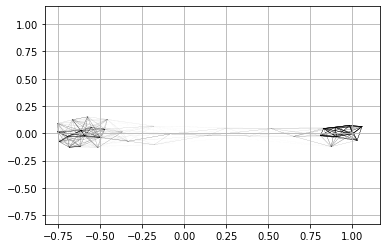

In [71]:
pca = PCA(n_components=2)
pca.fit(pos3)
x_pca = pca.transform(pos3)

plt.figure()
xx = x_pca[:,0]
yy = x_pca[:,1]

mm = min(xx)*1.1
MM = max(xx)*1.1


koef = 3
for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1,key2)['weight']
#             print(w)

            if w > 0.:
                plt.plot([xx[i1],xx[i2]],[yy[i1],yy[i2]],'k',linewidth=koef*w**2,zorder=1)

index = np.array(range(0,len(xx)))+1

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.grid()

Calculate the x-coordinate of each attitude

In [72]:
xcor_att = dict()
ycor_att = dict()

min_ = 1000
max_ = -min_

for i,key in enumerate(keys_vec):
    xcor_att[key] = xx[i]
    ycor_att[key] = yy[i]
    
    if xx[i]<min_:
        min_ = xx[i]
        
    if xx[i]>max_:
        max_= xx[i]

In [73]:
# renormalize x between -1 and 1

for key in xcor_att:
    val = xcor_att[key]
    
    val1 = (val-min_)/(max_-min_)
    val2 = (val1*2) - 1
    
    xcor_att[key] = val2

Calculate the x-coordinate for each person

In [74]:
quests = df_bool.columns
mean_x_cor_pep = []
std_x_cor_pep = []
mean_y_cor_pep = []

df1 = df_bool

n_norm= 1

x_transform = lambda vec: vec

for i,_ in enumerate(df1.iloc[:,0]): # for each person
    line = df1.iloc[i,:]
    
    ans = line[quests]
    
    x_cor_p = []
    y_cor_p = []
    
    for j,el in enumerate(quests[ans]):
        x_cor_p.append(xcor_att[el])
        y_cor_p.append(ycor_att[el])

    x_cor_p = np.array(x_cor_p)
    
    x_cor_p = x_transform(x_cor_p)
    
    mean_ = np.mean(x_cor_p)
    mean_x_cor_pep.append(mean_) 
    
    mean_y_cor_pep.append(np.mean(y_cor_p))
    
    std_x_cor_pep.append(np.std(x_cor_p))
    
df1["x_cor"] = mean_x_cor_pep
df1["y_cor"] = mean_y_cor_pep

df1["x_std"] = std_x_cor_pep
    

Re-test the hypotheses

### H1

In [75]:
corr_nan(-anes20_3.loc[df1.index]["PartyRegistr"], df1["x_cor"])

0.7367571384234852

### H2

In [76]:
corr_nan(anes20_3.loc[df1.index]["Thermo"], df1["x_cor"])

0.7858058164869851